# Vlasov-Poisson Mirror Model for Plasma Confinement (single-species regime)

## Electric Field Effect Study

We study the effect of the electric field $E(t,z)$ in our Vlasov-Poisson model for plasma confinement for an electron-only case.

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

from vp_solver.jax_mirror_solver import make_mesh, VlasovPoissonSolver
from vp_solver.utils_mirror import BFieldMLP, load_b_trained, cost_rho

from vp_solver.utils_plots import plot_magnetic_fields, plot_initial_distribution_single
from vp_solver.utils_plots import plot_final_distribution_single_E_effect, plot_energies
from vp_solver.utils_plots import plot_rhos_single, plot_int_rho_single


from matplotlib import colors

matplotlib.rcParams.update({
    'font.size': 16,  # General font size
    'axes.labelsize': 16,  # Axis label size
    'axes.titlesize': 26,  # Title size
    'xtick.labelsize': 18,  # X-tick label size
    'ytick.labelsize': 18,  # Y-tick label size
    'legend.fontsize': 16   # Legend font size
})

vcost_rho = jax.vmap(cost_rho, in_axes=(0,None), out_axes=0)

### Problem and solver setup

We solve

$$ \partial_t f_e
+
v\partial_z f_e
+
\left(
\frac{q_e}{m_e}E(t,z)
-
\mu \partial_z |\mathbf{B}(z)|
\right)\partial_v f_e
=
0,
$$

where
- $f_e(t,z,v,\mu)$ is the electron distribution,
- $q_e$ is the electron's charge,
- $m_e$ is the electron's mass,
- $\mathbf{B}(z)$ is the magnetic field,
- $E(t,z)$ is the electric field,
- $z \in [-L_z,L_z]$, $v \in \mathbb{R}$, $\mu\in\mathbb{R}_{+}$ and $t\in \mathbb{R}_{+}$.

The electric field is defined as $E(t,z) = -\partial_z \phi(t,z)$ where $\phi$ represents the electric potential and is obtained by solving the following Poisson equation:

$$\left\{\begin{array}{rcl}
-\partial_{zz}\phi
+
\partial_z\phi
\frac{\partial_z |\mathbf{B}(z)|}{|\mathbf{B}(z)|}
& = &
2\pi |\mathbf{B}(z)|
\iint
\left(
f_i - f_e
\right)
\,\mathrm{d}v\,\mathrm{d}\mu, \\
\phi(t,-L_z)
=
\phi(t,L_z)
&=&
0.
\end{array}
\right.
$$

We solve using a conservative semi-Lagrangian scheme with Strang operator splitting for time advancement.

In [2]:
# Setup for the forward solver
nz = 128
nv = 128
nmu = 128
dt = 0.1
t_final = 25.0
t_values = jnp.linspace(0, t_final, int(t_final / dt)+1)
LZ = 2*jnp.pi
LV = 4.0
LMU = 2.8 # Given that B_max = 10.0
zs = jnp.linspace(-LZ, LZ, nz, endpoint=True)

## B parameters
B_max = 10.0
B_min = 1.0

mirror_ratio = B_max/B_min
prop_trapped = jnp.sqrt((mirror_ratio - 1)/mirror_ratio)
print("Particles trapped: {:.3f}".format(prop_trapped))

Particles trapped: 0.949


In [3]:
# B definitions
B_fn_grid, dB_fn_grid, B_eval, dB_eval, g_eval = load_b_trained(0, zs)

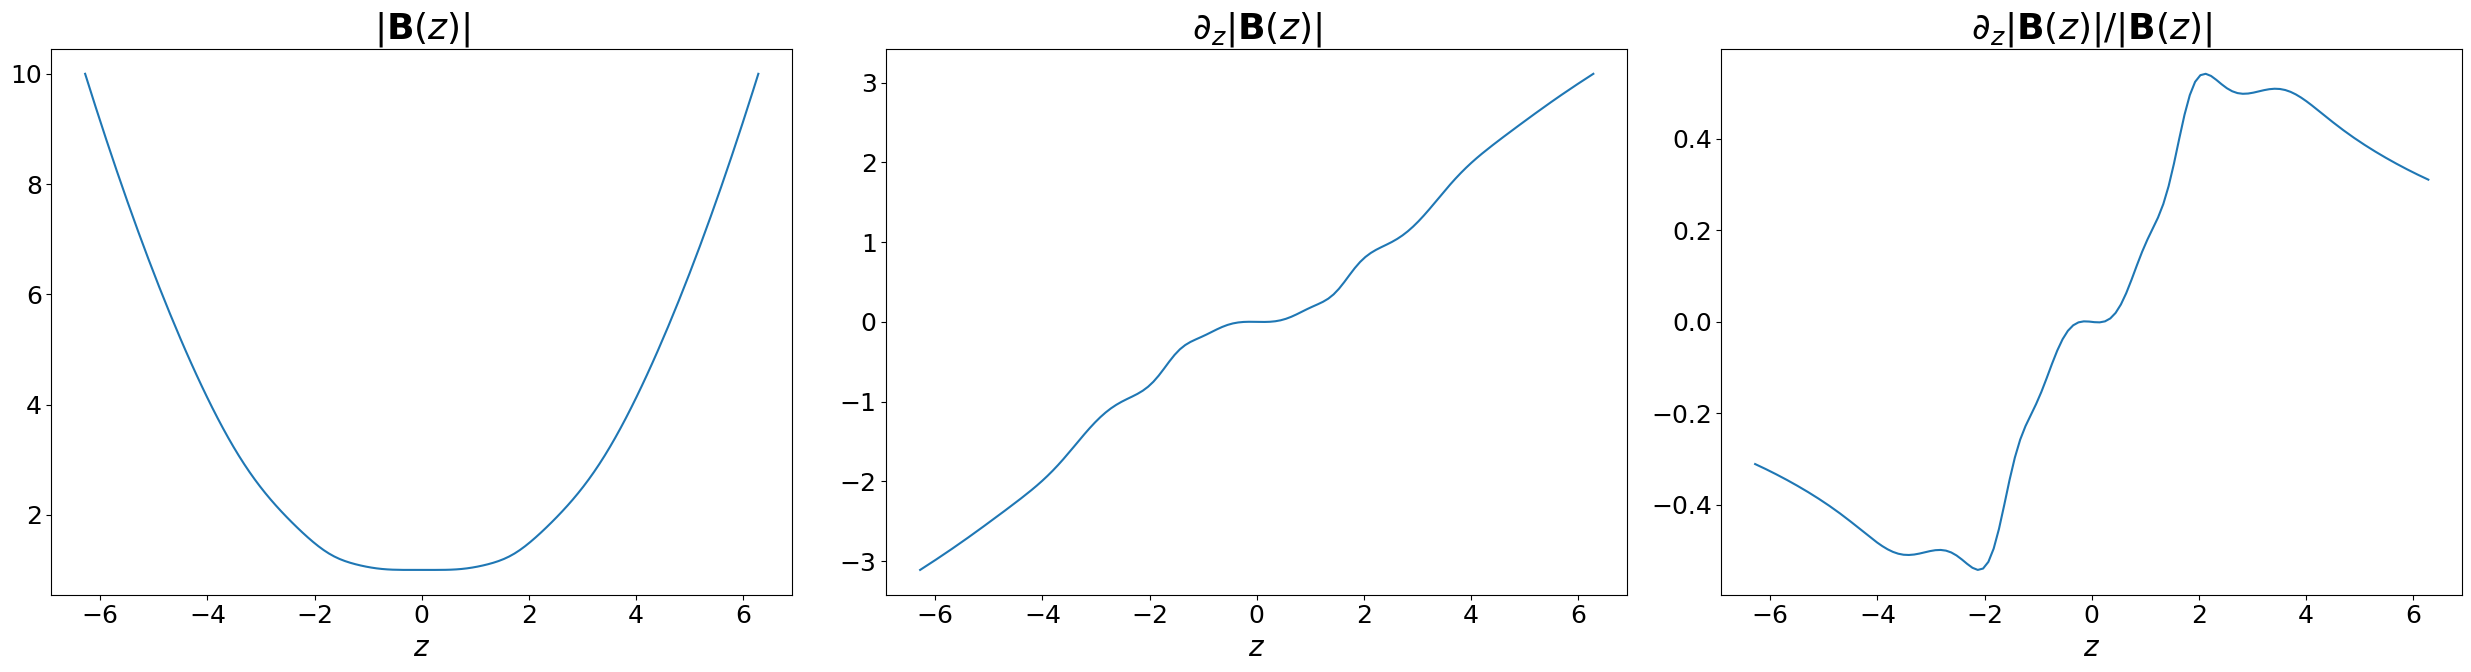

In [4]:
plot_magnetic_fields(B_eval, dB_eval, g_eval, zs)

In [5]:
mesh = make_mesh(length_z=LZ, 
    length_v=LV, length_mu=LMU,
    nz=nz, nv=nv, nmu=nmu
)

sigma_z = 0.8
f_eq_Z = jnp.exp(-mesh.Z**2/(2*sigma_z**2))


B_norm = B_fn_grid(mesh.Z)

f_eq = jnp.exp(-0.5*((mesh.V)**2 + 2*B_norm*mesh.MU)) #/ B_norm

analytical_Cz = B_fn_grid(mesh.zs)/jnp.sqrt(2*jnp.pi)
C_z = 1 / (jnp.trapezoid(jnp.trapezoid(f_eq, x=mesh.mus, axis=2), x=mesh.vs, axis=1))

f_iv = C_z[:,None,None] * f_eq_Z * f_eq

rho = jnp.trapezoid(jnp.trapezoid(f_iv, x=mesh.mus, axis=2), x=mesh.vs, axis=1)

D = 1 / (jnp.trapezoid(jnp.trapezoid(jnp.trapezoid(f_iv, x=mesh.mus, axis=2), x=mesh.vs, axis=1), x=mesh.zs, axis=0))

f_iv = D * f_iv

print("\\int\\rho dz: ", jnp.trapezoid(jnp.trapezoid(jnp.trapezoid(f_iv, x=mesh.mus, axis=2), x=mesh.vs, axis=1), x=mesh.zs, axis=0))

\int\rho dz:  1.0


#### Initial condition

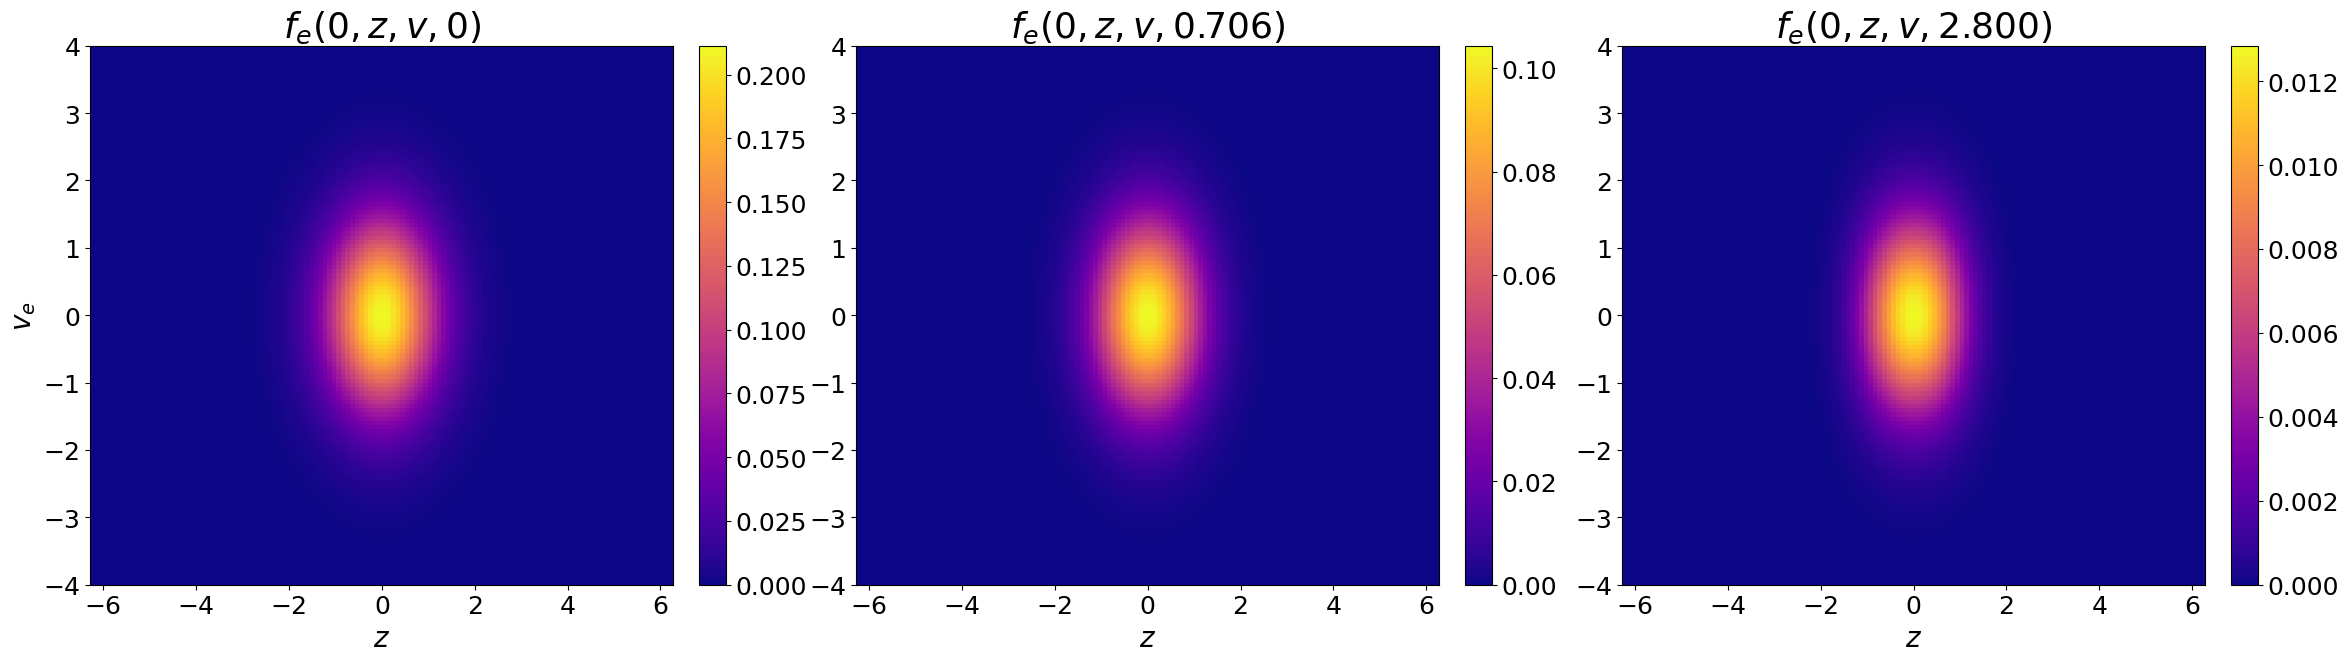

In [6]:
plot_initial_distribution_single(f_iv, mesh)

Since we are testing the effects of the electrical field we first simulate with $E(t,z)$ and then we simulate without $E(t,z)$ and see the differences.

In [7]:
solver = VlasovPoissonSolver(mesh=mesh, dt=dt)

# JIT-compiled forward solvers
solver_jit = jax.jit(solver.run_forward_jax_scan, static_argnames=('t_final',))
solver_jit_no_E = jax.jit(solver.run_forward_jax_scan_no_E, static_argnames=('t_final',))

### Numerical results

In [8]:
f_array, f_total, E_array, ee_array, rho_array = solver_jit(f_iv, B_eval, dB_eval, g_eval, t_final=t_final)
f_array_no_E, rho_array_no_E = solver_jit_no_E(f_iv, B_eval, dB_eval, g_eval, t_final=t_final)

In the figure below we plot on top the results without taking the electric field into acount and then with it. We see that the electric field has a positive effect in confinement in this scenario.

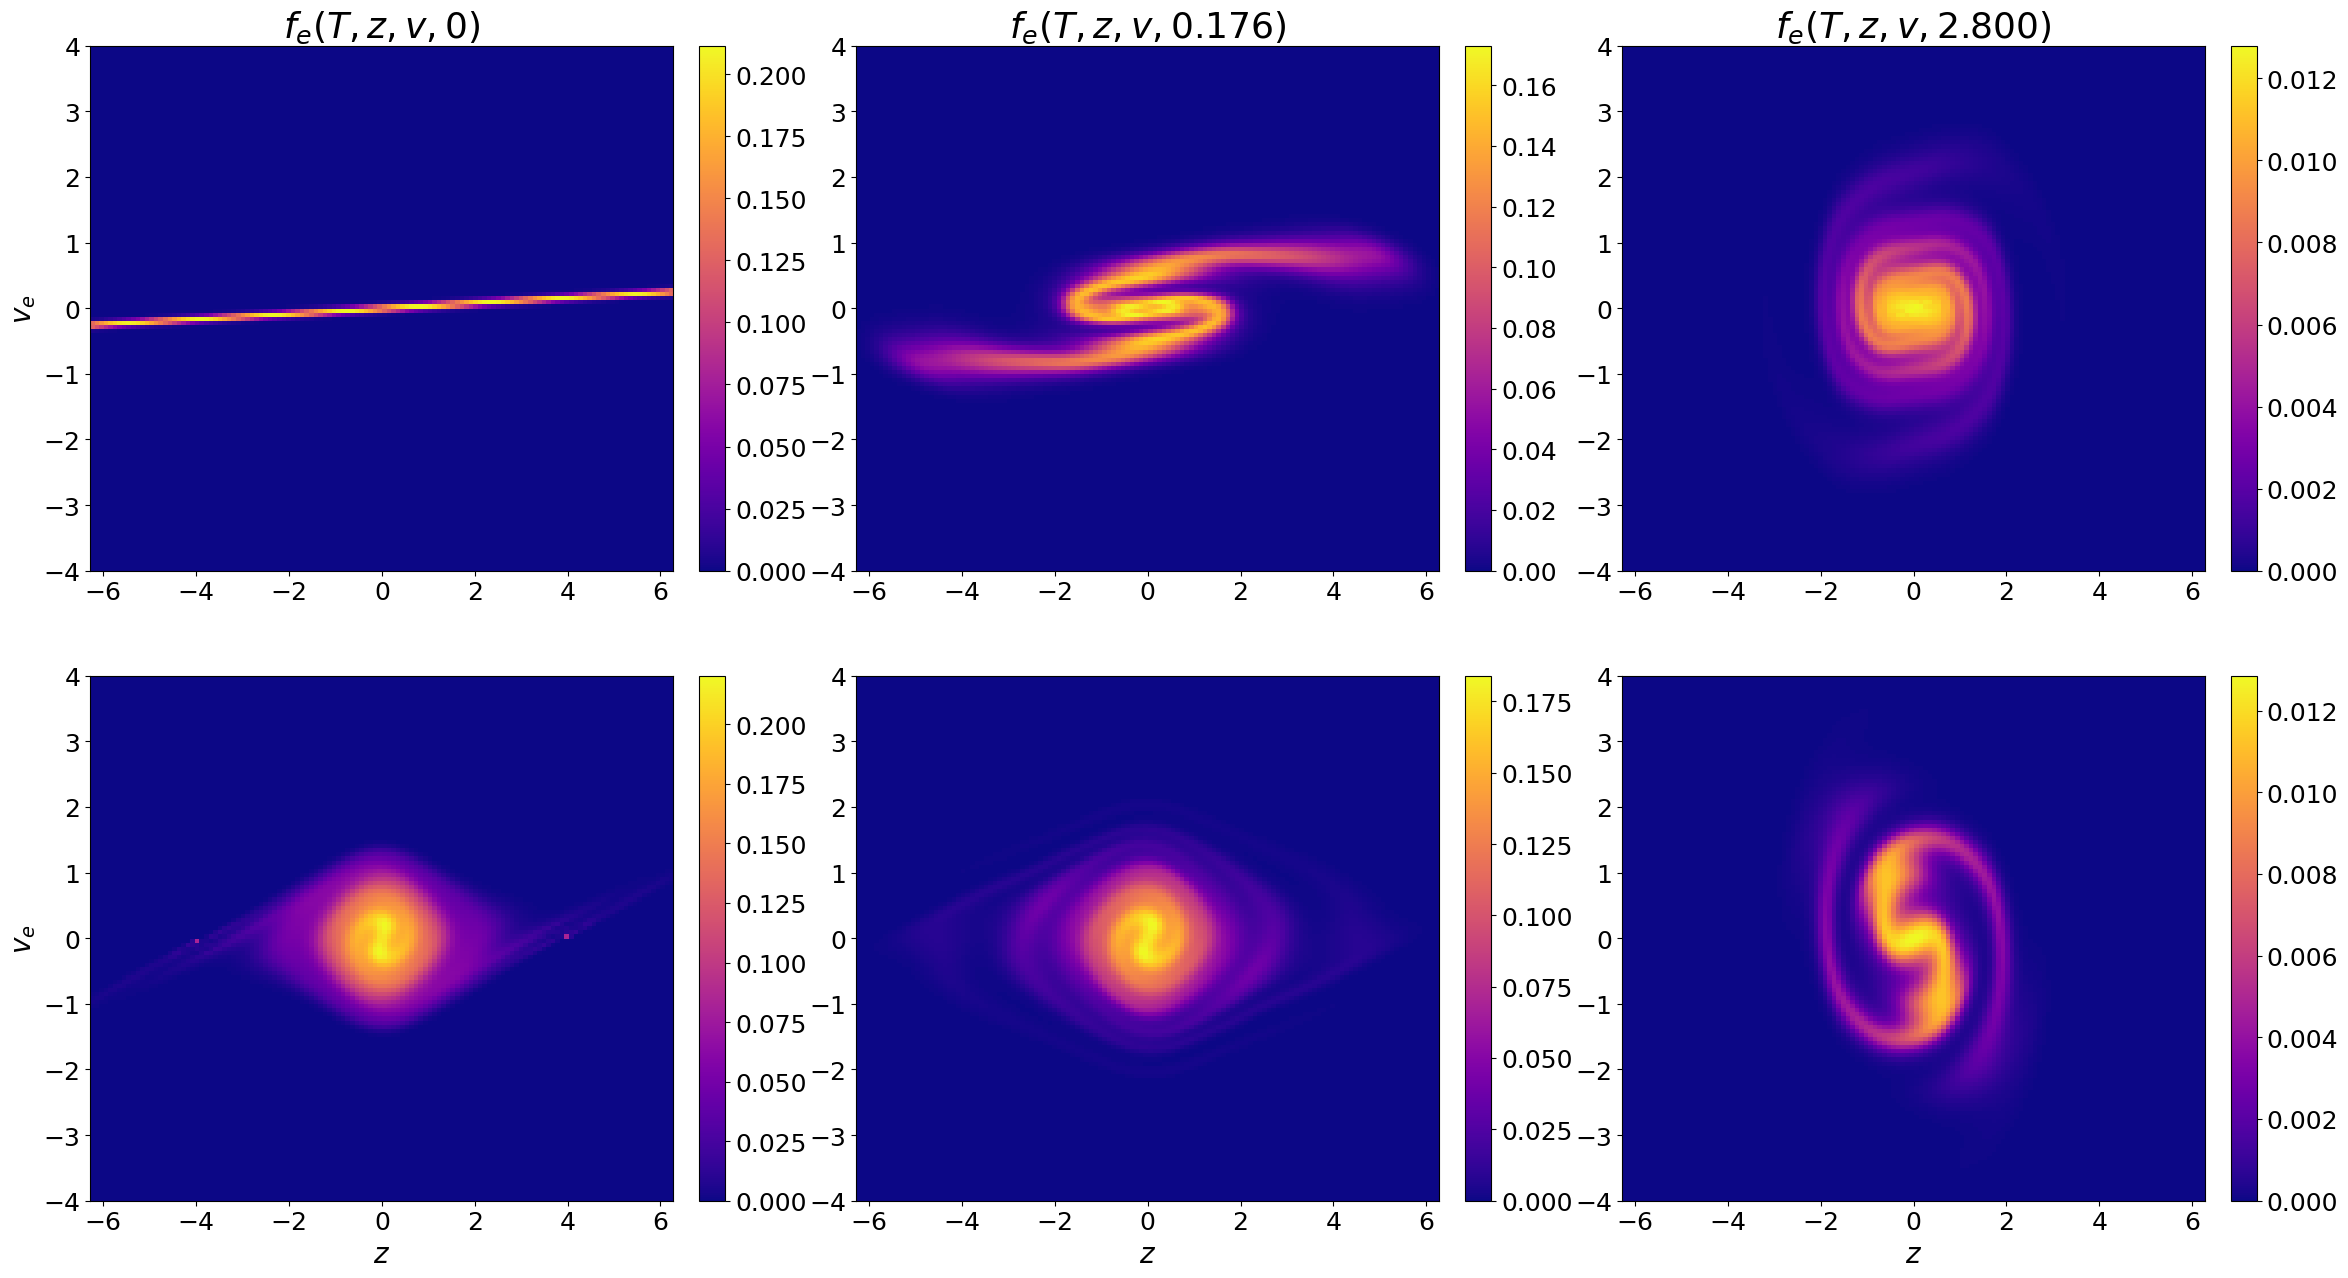

In [9]:
plot_final_distribution_single_E_effect(f_array, f_array_no_E, mesh)

We plot the electrical energy $\mathcal{E}(t)$ defined as

$$
\mathcal{E}(t) = \frac{1}{2}\int_{-L_z}^{L_z}E(t,z)^{2}\,\mathrm{d}z\,. 
$$

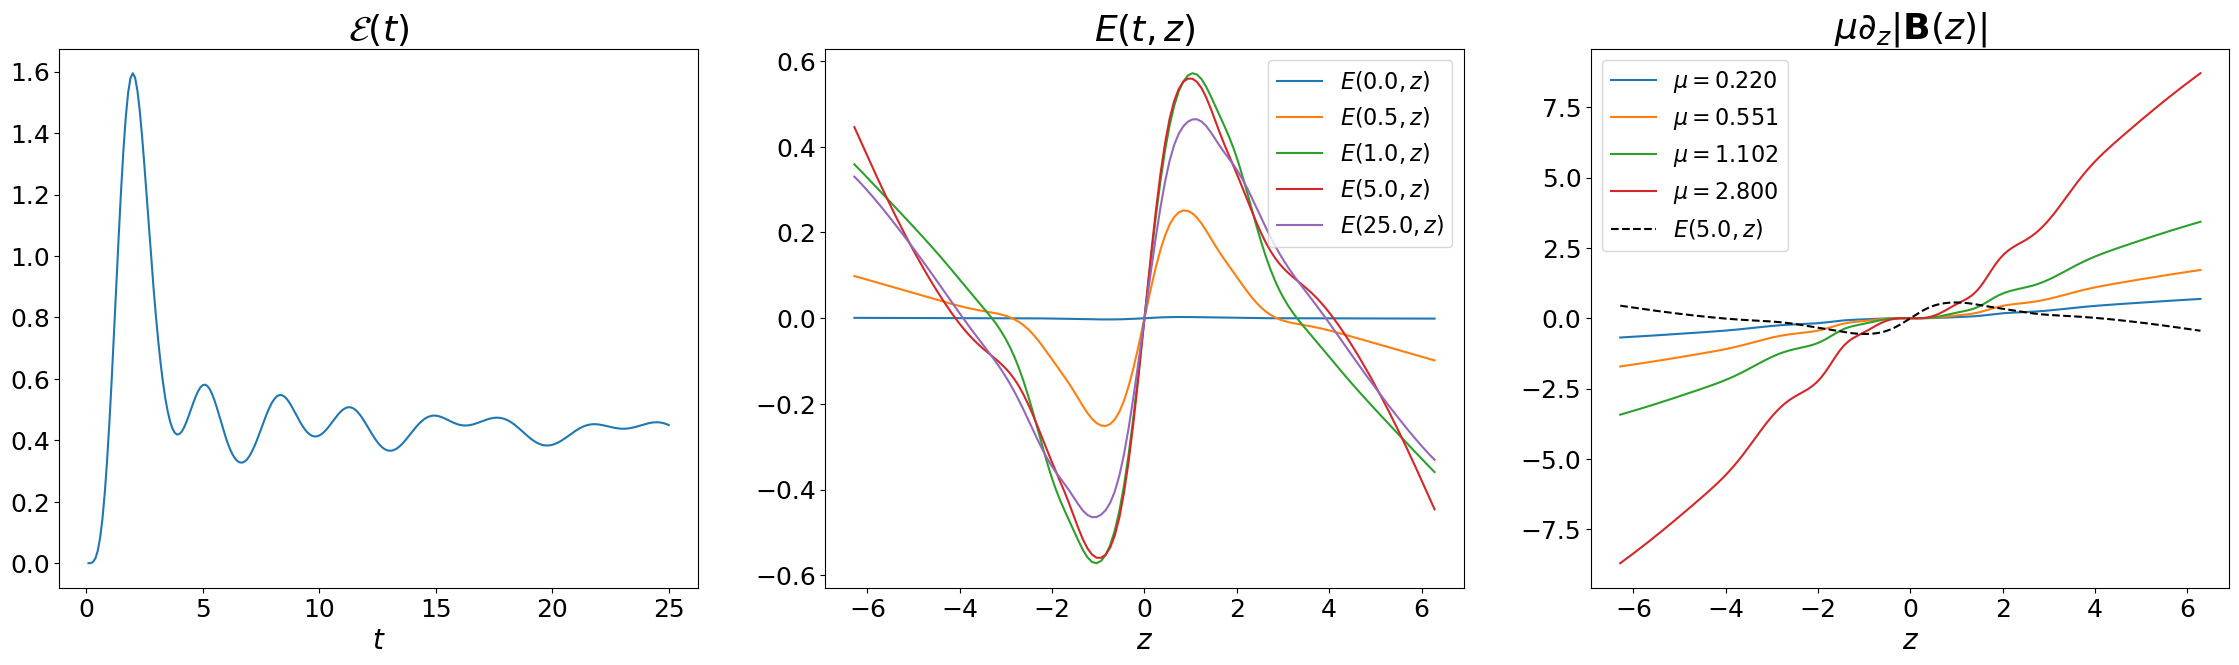

In [10]:
plot_energies(t_values, ee_array, E_array, dB_eval, mesh)

We plot two density quantities: the three-dimensional density, which is given by
$$
\rho_e(t,z)
=
2\pi |\mathbf{B}(z)|
\iint
f_e(t,z,v,\mu)
\,\mathrm{d}v\,\mathrm{d}\mu\,,
$$
and the effective longitudinal density, which is given by
$$
\rho_e^{1D}(t,z)
=
\iint
f_e(t,z,v,\mu)
\,\mathrm{d}v\,\mathrm{d}\mu\,.
$$

In addition, to see the level of confinement in time we plot

$$\int_{-L_z}^{L_z}\rho_e^{1D}(t,z)\,\mathrm{d}z\,.$$

Here, the effect of $E$ on confinement becomes much clearer.

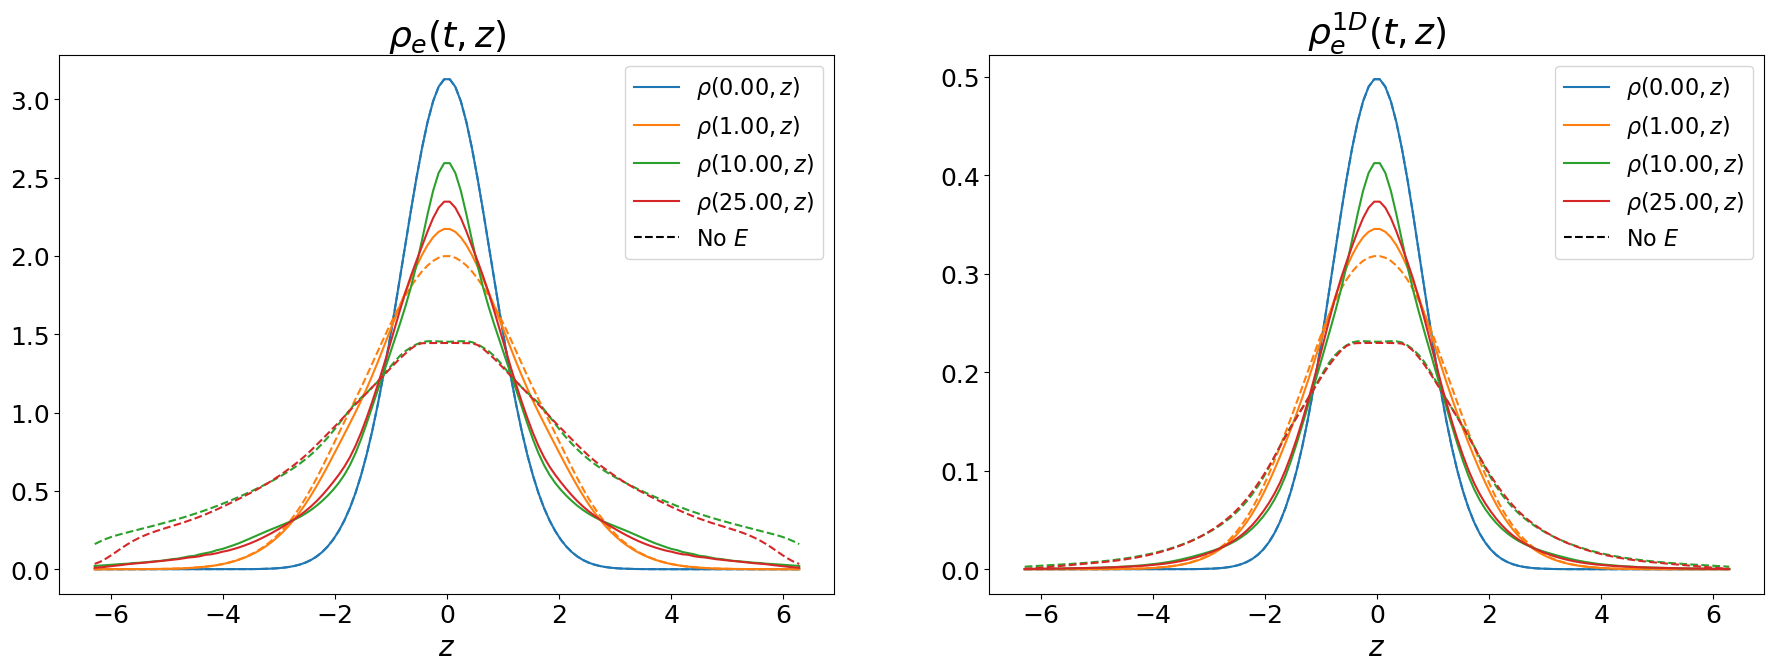

In [11]:
plot_rhos_single(rho_array, rho_array_no_E, B_eval, t_values, mesh)

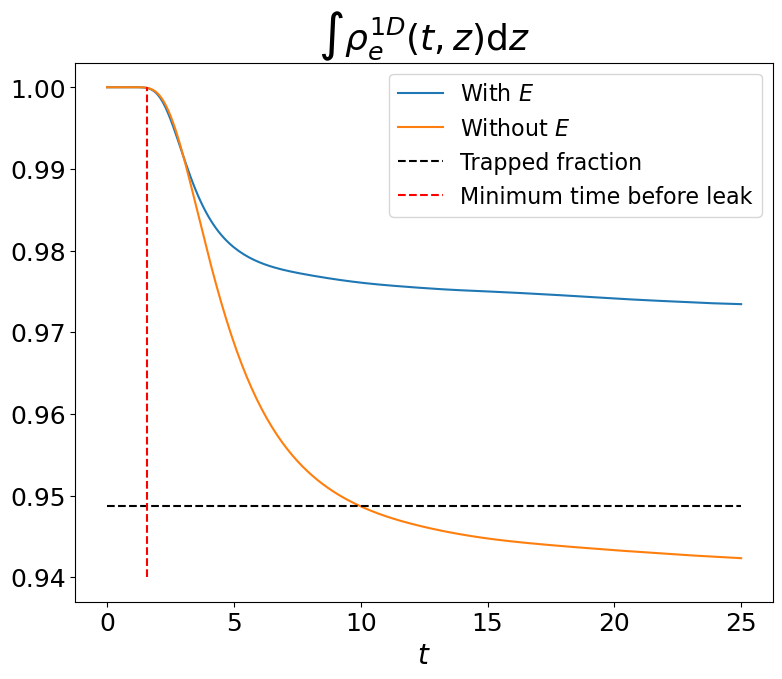

In [12]:
plot_int_rho_single(rho_array, rho_array_no_E, t_values, LZ, LV, prop_trapped, mesh)